# 15 - Targets: turning the panel into something we can predict

Everything up to here produced **features**. The panel (notebook 12) says what each company looked
like each month, the deltas (notebook 13) say how it changed, and the contract features (notebook 14)
say what public work it won. Not one of those is a target. There has been nothing to predict.

This notebook closes that gap. It stands in an origin month `t`, looks **forward** in the same panel,
and writes down whether the thing we care about happened by `t + H`. That is the whole of step 5, and
it is the payoff for building a time series in the first place: the future of the panel labels its own
past, so nobody has to hand-label anything.

The rule that everything else depends on: **features come from month `t`, labels come from `t+1 ... t+H`,
and never from `t` itself.** Break that and you get a model with a beautiful AUC that is worthless in
production, because in production `t+1` has not happened yet.

The logic lives in `src/models/targets.py`. This notebook drives it and, more importantly, checks it.

## The four labels

All four are conditioned on **Active at `t`**, because a company already in liquidation is not a
prospect and asking "will it become insolvent" is meaningless.

| index | label | H | measured base rate |
|---|---|---|---|
| Lending Readiness | `Mortgages.NumMortCharges` increases | 3m | 0.25 - 0.31% |
| Credit Risk Exposure | enters genuine insolvency | 6m | 0.30 - 0.41% |
| Voluntary Exit | status becomes "Proposal to Strike off" | 6m | 6.7 - 8.5% |
| Growth Signal | size band moves up | 12m | 2.1 - 2.2% |

Two traps I hit while scoping this, both of which changed the definitions:

**"Non-Active" is not distress.** The original plan defined the distress label as "Active at `t`,
non-Active by `t+H`". That runs at about 4%, but roughly **90% of it is voluntary strike-off**: dormant
micro-companies quietly closing. That is not a credit event and no bank wants it in a risk model.
Filtering to genuine insolvency drops it to ~0.34%. I model **both, separately**: insolvency as Credit
Risk Exposure, strike-off as Voluntary Exit. They are different questions with different audiences, and
blending them lets the loud one drown the important one.

**A note on the name.** I called this label Attrition until 26 July, and I have renamed it. Lloyds uses
"attrition" for a specific thing: a client moving their banking to a competitor, so we can try to win them
back. Strike-off is not that. A company proposing to strike itself off is winding down, and it is not a
relationship to recover, it is a dead company. Shipping our label under their word would have meant
answering a question they never asked while appearing to answer the one they did. So this is Voluntary
Exit, which says what it measures, and attrition is reserved for provider switching. That one I cannot
measure from the bulk file at all, because it needs to know *who* a company borrows from and the bulk file
only carries charge counts. It is being built separately from the Charges API in `src/features/charges.py`;
`reports/client-requirements.md` has the full picture.

**`segment` is not a size ladder.** It mixes real sizes (Micro, Small, Medium, Large) with filing states
(No Filings, Dormant, Subsidiary, Unknown). Naive "segment changed" is ~13% at 12 months and most of that
is `No Filings` <-> `Micro` churn, which is a filing event, not growth. The panel already carries
`tier_rank`, which ranks only the four real tiers and leaves the filing buckets NULL. Companies with no
rank are **excluded** from the growth label rather than squeezed in somewhere.

**Origins are quarterly.** That makes the 3-month lending windows non-overlapping, so each company-quarter
is an independent observation rather than fifteen near-copies of the same one. Distress and growth still
overlap 2x and 4x; the grouped CV in step 6 absorbs that.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
# Every default path in src/ is repo-root relative, so work from there.
os.chdir(REPO_ROOT)

import duckdb
import pandas as pd

from src.features import contracts, panel
from src.models import targets

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=6")

DELTA_GLOB = (REPO_ROOT / panel.DELTA_DIR / "**" / "*.parquet").as_posix()
LABEL_GLOB = (REPO_ROOT / targets.LABEL_DIR / "**" / "*.parquet").as_posix()

print(f"{len(targets.FEATURE_COLS)} features will go into the modelling matrix:")
print(f"  {len(targets.LEVEL_FEATURE_COLS)} level (from the panel at t)")
print(f"  {len(panel.DELTA_FEATURE_COLS)} delta (backward-looking)")
print(f"  {len(contracts.ASOF_FEATURE_COLS)} contract (as-of t)")
print(f"  {len(targets.CATEGORICAL_COLS)} categorical")

41 features will go into the modelling matrix:
  7 level (from the panel at t)
  25 delta (backward-looking)
  7 contract (as-of t)
  2 categorical


## First: does the insolvency mapping still cover every status?

The insolvency enumeration is lifted from Sneha's `is_insolvent` in
`notebooks/12_baseline_model.ipynb` (itself adapted from Sam's attrition work). It is the most valuable
single thing in that notebook and I am taking it wholesale, because without it the distress label is 90%
strike-off noise.

I did change one thing. Hers falls back to substring tests (`"administration" in s`). The panel has exactly
ten distinct statuses, so I would rather enumerate them and **fail loudly on an eleventh** than have a new
status quietly slip through a substring check and under-count insolvency forever. This assert is that guard.

In [2]:
status_counts = targets.check_statuses()
status_counts["insolvent"] = status_counts["status"].isin(targets.INSOLVENT_STATUSES)
status_counts

,status,n,insolvent
0,active,45802028,False
1,active - proposal to strike off,2927106,False
2,liquidation,785305,True
3,in administration,32856,True
4,voluntary arrangement,3822,True
5,in administration/administrative receiver,3046,True
6,live but receiver manager on at least one charge,1738,True
7,in administration/receiver manager,138,True
8,receivership,90,True
9,voluntary arrangement / receiver manager,23,True


## The origin grid

Quarterly, anchored on the first panel month. A target's usable origins stop where its label window would
run off the end of the register: past that point "nothing happened" really means "we cannot see yet",
which is not the same thing at all.

In [3]:
grid = pd.DataFrame([
    {"target": t, "horizon_m": h,
     "n_origins": len(targets.target_origins(t)),
     "first": min(targets.target_origins(t)).strftime("%Y-%m"),
     "last": max(targets.target_origins(t)).strftime("%Y-%m")}
    for t, (_, h) in targets.TARGETS.items()
])
grid

,target,horizon_m,n_origins,first,last
0,lending,3,11,2023-10,2026-04
1,insolvency,6,10,2023-10,2026-01
2,voluntary_exit,6,10,2023-10,2026-01
3,growth,12,8,2023-10,2025-07


## Build the labels

One query, not a per-month loop: the forward windows need the whole history in scope, same as the delta
build.

The windows are DuckDB `RANGE` frames keyed on the calendar date (`INTERVAL 1 MONTH FOLLOWING` to
`INTERVAL H MONTH FOLLOWING`), **not** positional offsets. This matters for exactly the reason it mattered
in notebook 13: June 2025 does not exist. A positional frame would silently reach an extra month past the
hole. A calendar range just gets no row for June and carries on. Where a window contains no observed month
at all, the label is NULL, never 0.

In [4]:
n_labels = targets.build_labels(threads=6)
print(f"label rows: {n_labels:,}")

n_active = con.execute(f"""
    SELECT count(*) FROM read_parquet('{DELTA_GLOB}')
    WHERE is_active AND snapshot_date IN
        ({', '.join(f"DATE '{m:%Y-%m-%d}'" for m in targets.origin_months())})
""").fetchone()[0]
print(f"active companies at those origins: {n_active:,}")
assert n_labels == n_active, "label table should be exactly the active-at-origin rows"
print("PASS: one label row per company-origin, no more and no less.")

label rows: 16,653,498
active companies at those origins: 16,653,498
PASS: one label row per company-origin, no more and no less.


## The check that actually matters: base rates

This is the cheapest possible test that the labels mean what I think they mean, and it catches almost
every labelling mistake. A label that should be a third of a percent coming out at 20% is not a subtle
bug, it is a broken definition, and no amount of downstream modelling will rescue it.

In [5]:
rates = targets.check_base_rates()
pivot = rates.pivot(index="origin_month", columns="target", values="base_rate")
(pivot * 100).round(3)

target,growth,insolvency,lending,voluntary_exit
origin_month,,,,
2023-10-01,2.054,0.325,0.272,6.723
2024-01-01,2.076,0.324,0.257,7.160
2024-04-01,2.074,0.340,0.257,7.640
2024-07-01,2.064,0.388,0.275,8.043
2024-10-01,2.084,0.409,0.310,8.336
2025-01-01,2.096,0.360,0.246,8.411
2025-04-01,2.121,0.313,0.288,8.011
2025-07-01,2.153,0.295,0.287,8.450
2025-10-01,NaN,0.328,0.283,8.236


Lending and insolvency land almost exactly where the scoping note predicted (0.25-0.31% and 0.30-0.41%),
and they are **stable across origins**, which is good news for the out-of-time split: there is no drift to
explain away later.

Voluntary exit, though, comes out at 6.7-8.5% where my earlier note said 3.4-3.8%. That is a 2x gap and it needs
an explanation rather than a shrug.

## Reconciling voluntary exit: event vs state

The answer turned out to be a definitional difference, and it is worth writing down because it applies to
every label here.

My earlier note measured the **state at `t+H`**: is this company sitting in "Proposal to Strike off" in
month `t+6`. My label measures the **event anywhere in `t+1 ... t+6`**: did a strike-off proposal appear at
any point in the window.

For lending and insolvency the two are nearly the same, because a charge count only climbs and liquidation
does not reverse. For strike-off they differ by 2x, because proposals are routinely **withdrawn** once a
company files its overdue accounts. The cell below verifies this rather than asserting it.

In [6]:
recon = con.execute(f"""
    WITH a AS (
        SELECT "CompanyNumber" AS cn, snapshot_date AS m,
               lower(trim("CompanyStatus")) AS s
        FROM read_parquet('{DELTA_GLOB}')
        WHERE snapshot_date IN (DATE '2024-01-01', DATE '2024-07-01')
    )
    SELECT count(*) AS active_at_t,
           avg((h.s = 'active - proposal to strike off')::INT) AS strikeoff_state_at_t6,
           avg((h.s <> 'active')::INT)                          AS nonactive_state_at_t6
    FROM a t LEFT JOIN a h ON h.cn = t.cn AND h.m = DATE '2024-07-01'
    WHERE t.m = DATE '2024-01-01' AND t.s = 'active'
""").df()
recon

,active_at_t,strikeoff_state_at_t6,nonactive_state_at_t6
0,1371644,0.034908,0.038239


3.49% state-at-`t+6`, against 7.16% event-in-window for the same origin. So the old number was right for
what it measured, and the gap is entirely proposals raised and then withdrawn inside the six months.

**I am keeping the event definition** for two reasons. A proposal raised and withdrawn is still the moment
a relationship manager wanted to know about, so it is the more useful signal. And a state read off a single
month is hostage to that month existing, which given June 2025 is not a property I want any label to
depend on. I have updated the expected base rates in `targets.py` to match.

## Assemble and sample the modelling matrix

Features at `t` LEFT JOIN the contract features as-of `t`, then the label. Contract counts and flags mean
"none" when a company is absent from the sparse as-of table, so they coalesce to 0;
`months_since_last_award` has no zero-equivalent ("never won anything" is a true NULL) and is left alone.
`contracts.ASOF_COALESCE_ZERO` is the authority on which is which.

Then the sampling: **keep every positive, downsample negatives to 10x**. At a 0.3% base rate, 1.4M rows per
origin is almost entirely negatives that teach the model nothing, and carrying them costs real time.

Three details worth knowing:

- Sampling is done **per origin**, so the origin mix is preserved for the out-of-time split.
- Negatives are selected by a **hash of the company number**, not a random draw. That makes the sample
  reproducible without threading a seed through DuckDB, and it keeps the choice consistent for a company
  across origins, which is one less thing for the grouped CV to worry about.
- `neg_keep_rate` rides along as a column on every row, because **step 6 has to undo this**. Downsampling
  negatives inflates every predicted probability. The ranking survives it; the numbers do not.

`contracts_dir` is the A/B switch from step 4b. Point it at `contracts.ASOF_EXT_DIR` to rebuild with the
name-matched contract rows and compare out-of-time AUC in step 6.

In [7]:
summaries = []
for name in targets.TARGETS:
    s = targets.build_matrix(name, threads=6)
    summaries.append(s)
    print(f"{name:11s} {s['rows'].sum():>9,} rows  {int(s['positives'].sum()):>8,} positives  "
          f"sampled rate {s['sampled_rate'].mean():.3%}", flush=True)

summary = pd.concat(summaries, ignore_index=True)
summary

lending       457,941 rows    41,788 positives  sampled rate 9.124%


insolvency    520,142 rows    47,262 positives  sampled rate 9.087%


voluntary_exit 11,917,730 rows  1,083,664 positives  sampled rate 9.093%


growth      1,657,611 rows   150,806 positives  sampled rate 9.098%


,target,horizon_m,origin_month,rows,positives,sampled_rate,neg_keep_rate
0,lending,3,2023-10-01,40583,3689.0,0.090900,0.027226
1,lending,3,2024-01-01,38747,3519.0,0.090820,0.025721
2,lending,3,2024-04-01,39232,3571.0,0.091023,0.025768
3,lending,3,2024-07-01,42099,3841.0,0.091237,0.027574
4,lending,3,2024-10-01,47233,4314.0,0.091334,0.031050
5,lending,3,2025-01-01,37315,3407.0,0.091304,0.024643
6,lending,3,2025-04-01,43655,3987.0,0.091330,0.028869
7,lending,3,2025-07-01,43467,3976.0,0.091472,0.028769
8,lending,3,2025-10-01,43038,3940.0,0.091547,0.028337
9,lending,3,2026-01-01,39079,3568.0,0.091302,0.025824


Sampled positive rate is ~9.1% everywhere, which is exactly 1/11 and confirms the 1:10 downsampling did
what it was told. Note how far the `neg_keep_rate` varies by target: lending keeps under 3% of negatives,
voluntary exit keeps 72-92% of them (its base rate is high enough that 10x barely bites). That column is the
one step 6 must not lose.

## Verification

Three things I want to see before handing this to step 6.

### 1. No leakage

Structurally this holds by construction: every feature comes from the `panel_deltas` row at
`snapshot_date = origin_month`, every delta there was verified backward-looking in notebook 13, and the
contract as-of table gates on `publication_date <= month end`. But structure is an argument, not evidence,
so here is the evidence: if any feature were secretly the answer, it would show up as a near-1 correlation.

In [8]:
lending = pd.read_parquet(REPO_ROOT / targets.MATRIX_DIR / "lending")
numeric = lending[[c for c in targets.FEATURE_COLS
                   if c not in targets.CATEGORICAL_COLS]].apply(pd.to_numeric, errors="coerce")
corr = numeric.corrwith(lending["y"]).abs().sort_values(ascending=False)

assert corr.max() < 0.8, "a feature is suspiciously close to the label - check for leakage"
print(f"max |corr| with y_lending: {corr.max():.3f}  (no leakage)")
corr.head(8).round(3)

max |corr| with y_lending: 0.367  (no leakage)


tier_rank                     0.367
debt_ratio                    0.360
new_charge_events_12m         0.271
d_charges_12m                 0.207
Mortgages.NumMortSatisfied    0.183
d_charges_6m                  0.183
company_age_years             0.163
d_charges_3m                  0.161
dtype: float64

0.37 at the top, and the ordering is economically sensible: bigger companies (`tier_rank`), companies
already carrying debt (`debt_ratio`), and companies that have been taking on charges recently
(`new_charge_events_12m`, `d_charges_12m`) are the ones most likely to take on another. That is exactly
what a lending-readiness model should be picking up, and it is a decent sign that step 6 has something to
work with.

strongest |r| anywhere in the grid: 0.367
  Lending Readiness      0.367  (tier_rank)
  Credit Risk Exposure   0.136  (accounts_overdue)
  Voluntary Exit         0.245  (confstmt_late)
  Growth Signal          0.184  (tier_rank)


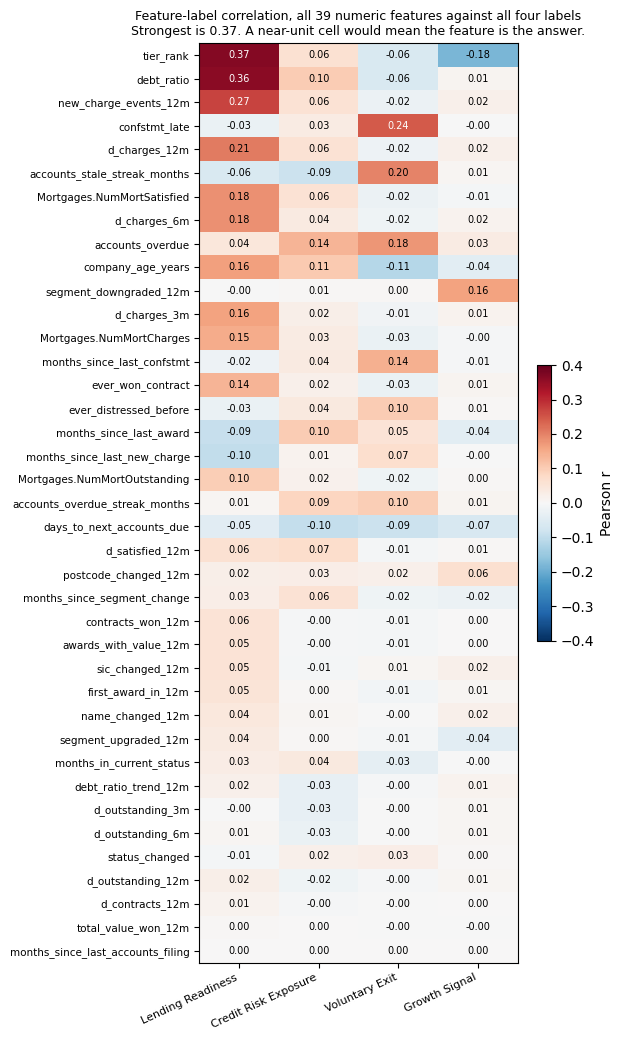

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.models import report

ORDER = ["lending", "insolvency", "voluntary_exit", "growth"]
NICE = {"lending": "Lending Readiness", "insolvency": "Credit Risk Exposure",
        "voluntary_exit": "Voluntary Exit", "growth": "Growth Signal"}
FEATS = [c for c in targets.FEATURE_COLS if c not in targets.CATEGORICAL_COLS]

# One query per target: Pearson r between every numeric feature and that target's y,
# read straight off the sampled matrix the model actually trains on.
grid = {}
for t in ORDER:
    cols = ",\n           ".join(f'corr("{f}"::DOUBLE, y::DOUBLE) AS "{f}"' for f in FEATS)
    matrix = (REPO_ROOT / targets.MATRIX_DIR / t / "**" / "*.parquet").as_posix()
    grid[t] = con.execute(f"SELECT {cols} FROM read_parquet('{matrix}')").df().iloc[0].astype(float)

grid = pd.DataFrame(grid)[ORDER]
grid = grid.loc[grid.abs().max(axis=1).sort_values(ascending=False).index]

assert grid.abs().max().max() < 0.8, "a feature is suspiciously close to a label - check for leakage"
print(f"strongest |r| anywhere in the grid: {grid.abs().max().max():.3f}")
for t in ORDER:
    print(f"  {NICE[t]:22s} {grid[t].abs().max():.3f}  ({grid[t].abs().idxmax()})")

fig, ax = plt.subplots(figsize=(6.2, 10.5))
m = grid.values
im = ax.imshow(m, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-0.4, vcenter=0.0, vmax=0.4), aspect="auto")
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(m[i, j]) > 0.22 else "black")
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([NICE[t] for t in ORDER], rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(len(grid)))
ax.set_yticklabels(grid.index, fontsize=7.5)
ax.set_title("Feature-label correlation, all 39 numeric features against all four labels\n"
             "Strongest is 0.37. A near-unit cell would mean the feature is the answer.", fontsize=9)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.3, label="Pearson r")
fig.tight_layout()
report.save_fig(fig, "15_feature_label_corr")
plt.show()

The same test, widened to the whole grid: every numeric feature against every one of the four
labels, not just lending. Nothing changes the verdict, and it is the version I want in the report,
because "we checked one label" is a weaker sentence than "we checked all of them". Saved to
`reports/figures/15_feature_label_corr.pdf` so the write-up can point at it.

One caveat worth stating: these are correlations on the **sampled** matrices, the same rows each
model trains on, so they are the numbers that matter for leakage rather than population
correlations.

0.367 is the strongest cell anywhere in the grid, and each label's own top feature reads the way it
should: lending on `tier_rank` and `debt_ratio`, voluntary exit on `confstmt_late` and stale
accounts, insolvency on `accounts_overdue`, growth on `tier_rank` (negative, small companies have
more room to move up a band). No feature is secretly the answer to any of the four.

### 2. The June 2025 hole is handled

Same test as notebook 13, but on the label side. The 2025-04 origin has a 3-month window covering May,
June and July 2025. June does not exist. If the calendar range worked, that origin should still have a
perfectly normal label built from May and July, and **not** be silently NULL or silently reaching into
August.

In [10]:
gap = con.execute(f"""
    SELECT origin_month,
           count(*)             AS rows,
           count(y_lending)     AS labelled,
           avg(y_lending::DOUBLE) AS base_rate
    FROM read_parquet('{LABEL_GLOB}')
    WHERE origin_month IN (DATE '2025-01-01', DATE '2025-04-01', DATE '2025-07-01')
    GROUP BY 1 ORDER BY 1
""").df()

straddling = gap[gap["origin_month"] == pd.Timestamp("2025-04-01")].iloc[0]
assert straddling["labelled"] == straddling["rows"], "gap month nulled out a whole origin"
print("PASS: the origin whose window straddles the missing June 2025 is fully labelled,")
print("      and its base rate sits between its neighbours rather than dropping.")
gap

PASS: the origin whose window straddles the missing June 2025 is fully labelled,
      and its base rate sits between its neighbours rather than dropping.


,origin_month,rows,labelled,base_rate
0,2025-01-01,1385937,1385935,0.002458
1,2025-04-01,1385063,1385063,0.002879
2,2025-07-01,1386031,1386027,0.002869


### 3. The early origins are feature-poor, and step 6 needs to know

This one is not a bug but it is a trap. The panel starts 2023-10, so a 12-month delta cannot exist until
2024-10, and at the 2023-10 origin **every** delta is NULL because there is no earlier month at all.

The labels there are perfectly valid and the level features are real, so I label those origins anyway. But
the missingness is a calendar artefact, and in an out-of-time split it lands entirely in train and never in
test. That is precisely the kind of pattern a tree will happily split on and then find missing at test time.

`targets.FIRST_FULL_ORIGIN` (2024-10) marks where every feature is properly formed. Lending, insolvency and
voluntary exit can afford to start there. Growth cannot: it would be left with 4 origins, so there it is a real
trade against sample size and step 6 has to make a call.

In [11]:
nulls = con.execute(f"""
    SELECT origin_month,
           round(avg((d_charges_3m  IS NULL)::INT), 3) AS null_d_charges_3m,
           round(avg((d_charges_12m IS NULL)::INT), 3) AS null_d_charges_12m
    FROM read_parquet('{(REPO_ROOT / targets.MATRIX_DIR / "lending" / "**" / "*.parquet").as_posix()}')
    GROUP BY 1 ORDER BY 1
""").df()

usable = {t: sum(m >= targets.FIRST_FULL_ORIGIN for m in targets.target_origins(t))
          for t in targets.TARGETS}
print(f"origins at or after FIRST_FULL_ORIGIN ({targets.FIRST_FULL_ORIGIN:%Y-%m}): {usable}")
nulls

origins at or after FIRST_FULL_ORIGIN (2024-10): {'lending': 7, 'insolvency': 6, 'voluntary_exit': 6, 'growth': 4}


,origin_month,null_d_charges_3m,null_d_charges_12m
0,2023-10-01,1.000,1.000
1,2024-01-01,0.036,1.000
2,2024-04-01,0.041,1.000
3,2024-07-01,0.037,1.000
4,2024-10-01,0.033,0.139
5,2025-01-01,0.032,0.135
6,2025-04-01,0.038,0.132
7,2025-07-01,0.038,0.134
8,2025-10-01,0.039,0.139
9,2026-01-01,0.036,0.142


## Where this leaves step 6

On disk now:

- `data/processed/labels/` - one row per (company, quarterly origin), four 0/1 columns, NULL where the
  window runs off the panel or the label does not apply.
- `data/processed/model_matrix/{lending,insolvency,voluntary_exit,growth}/` - features joined to the label,
  negatives downsampled 1:10, `neg_keep_rate` carried on every row.

Step 6 picks these up and does the modelling. In order:

1. **Split out of time, with an embargo of at least `H`.** Train on early origins, test on late ones, and
   leave a gap at least as wide as the horizon between them, or a training row from month `t` has a label
   that resolves inside the test window and the model is being trained on the answer to its own exam.
   Grouped CV by `CompanyNumber` as a secondary check. Not `train_test_split`: a company appears at up to
   11 origins, so a random split leaks it across both sides.
2. **Logistic regression as an interpretable floor, then LightGBM.** If the boosting cannot clearly beat a
   regularised linear model on the same features, it is not earning its complexity and I should say so.
   The signed coefficients are also an independent check that the SHAP directions make economic sense.
3. **Precision@top-N (100, 500, 1000) as the headline metric**, with ROC-AUC and PR-AUC alongside. A
   relationship manager works a finite call list, so "of our top 500 picks, how many were right" is the
   question that matters. AUC over 1.4M companies does not answer it.
4. **Recalibrate with `neg_keep_rate`** before quoting any probability.
5. **SHAP via `TreeExplainer`** on a stratified ~100k subsample.
6. **Score the latest partition filtered to `is_active`**, rank, and enrich only the top few hundred through
   `src/features/ch_api.py`. Score wide and cheap, enrich narrow and expensive.

One thing to carry forward: the last two panel months (2026-06, 2026-07) are censored for contract features
because the Find a Tender bulk file stops at 2026-06-05. `build_matrix` already refuses to train past that
watermark, but scoring runs on 2026-07, so the contract features there are a slight undercount. Fine to
score on, and worth remembering before anyone reads too much into a contract-driven SHAP value on the
latest month.